# Study 953 — Replicating the Convert — the teardown

Sharpe-style constrained replication of CWB on SPY/QQQ/LQD/BIL, fitted in-sample and frozen; the hold-out residual with a Newey-West *t* and a circular block-bootstrap CI; the convexity battery (tercile smile, up-/down-capture, Treynor-Mazuy γ) run *against the replica*; era cut, annual refit, cost/fee sweep, ICVT cross-check, and the live synthetic control. Every real number is frozen from `docs/results.md` (Fingerprint `5e5674563124`, as-of 2026-06-30).

> 💡 **In plain words** — we build the cheapest possible copy of a convertible fund out of three ordinary ETFs, lock the recipe before the years we grade it on, and then ask whether the fund did anything the copy did not.

In [1]:
R = {'start': '2009-04-16', 'end': '2026-06-30', 'n_days': 4328, 'fp': '5e5674563124', 'is_end': '2017-12-31', 'oos_start': '2018-01-02', 'w_spy': 36.7, 'w_qqq': 20.2, 'w_lqd': 5.8, 'w_cash': 37.3, 'r2_is': 0.703, 'te_is': 5.68, 'fit_intercept': 1.12, 'alpha_is': 1.28, 't_is': 0.8, 'n_is': 2193, 'alpha_oos': 1.8, 't_oos': 0.58, 'te_oos': 8.3, 'corr_oos': 0.85, 'n_oos': 2134, 'ci_lo': -4.47, 'ci_hi': 7.55, 'ci_pos': 71.4, 'sharpe_fund': 0.662, 'sharpe_repl': 0.725, 'sharpe_gap': -0.063, 'vol_fund': 15.51, 'vol_repl': 11.69, 'dd_fund': -32.24, 'dd_repl': -19.46, 'dd_repl_volmatched': -25.25, 'm_r2': 0.764, 'm_te': 7.85, 'n_months': 102, 'ter_low': -55.8, 'ter_mid': 29.9, 'ter_high': 72.5, 't_low': -1.57, 't_high': 1.56, 'smile': -21.6, 't_smile': -0.5, 'up_cap': 1.219, 'dn_cap': 1.215, 'asym': 0.004, 'tm_gamma': 0.192, 't_tm': 0.25, 'era_e_alpha': 4.68, 'era_e_t': 0.86, 'era_e_n': 1008, 'era_l_alpha': -0.78, 'era_l_t': -0.23, 'era_l_n': 1126, 'refit_alpha': 1.35, 'refit_t': 0.61, 'refit_n': 3141, 'cost0_alpha': 1.69, 'cost0_t': 0.54, 'cost10_alpha': 1.91, 'cost10_t': 0.62, 'kit_spy_alpha': 3.01, 'kit_spy_t': 0.92, 'kit_spylqd_alpha': 2.99, 'kit_spylqd_t': 0.94, 'kit_spyqqq_alpha': 1.81, 'kit_spyqqq_t': 0.57, 'n_specs': 11, 'max_spec_t': 0.94, 'split_best_alpha': 2.35, 'split_best_t': 0.9, 'split_worst_alpha': -2.72, 'split_worst_t': -0.8, 'icvt_alpha': -2.16, 'icvt_t': -0.56, 'icvt_up': 0.802, 'icvt_dn': 0.871, 'icvt_n': 1378, 'mar20_fund': -13.28, 'mar20_repl': -6.49, 'mar20_gap': -6.79, 'fund_fee': 0.4, 'replica_fee_bps': 10, 'syn_alpha': 5.02, 'syn_t': 3.97, 'syn_gamma': 0.73, 'syn_t_gamma': 3.45, 'syn_smile': 26.7, 'syn_null_mean': 0.03, 'syn_null_sd': 0.87, 'syn_null_fire': 0}

## 1. The constrained fit (in-sample only)

Minimise ``||y − a − Xw||²`` over a free intercept and ``w ∈ {w ≥ 0, Σw ≤ 1}`` (Sharpe 1992 style analysis), on daily excess-of-cash total returns through **2017-12-31**. The residual budget is cash, so the replica is a genuine long-only portfolio and no borrow cost arises.

In [2]:
print(f"in-sample {R['n_is']:,} days -> {R['is_end']}")
for leg, w in [('SPY', R['w_spy']), ('QQQ', R['w_qqq']), ('LQD', R['w_lqd']), ('BIL', R['w_cash'])]:
    print(f'  {leg}  {w:5.1f}%')
print(f"  equity total {R['w_spy']+R['w_qqq']:.1f}%  |  credit {R['w_lqd']:.1f}%  |  cash {R['w_cash']:.1f}%")
print(f"  R2 {R['r2_is']:.3f}   TE {R['te_is']:.2f}%/yr   fit intercept {R['fit_intercept']:+.2f}%/yr")
print(f"  in-sample residual vs the costed replica {R['alpha_is']:+.2f}%/yr (HAC t {R['t_is']:+.2f})")
print('  the long-only budget never binds: the unconstrained OLS solution is identical to 3 dp')

in-sample 2,193 days -> 2017-12-31
  SPY   36.7%
  QQQ   20.2%
  LQD    5.8%
  BIL   37.3%
  equity total 56.9%  |  credit 5.8%  |  cash 37.3%
  R2 0.703   TE 5.68%/yr   fit intercept +1.12%/yr
  in-sample residual vs the costed replica +1.28%/yr (HAC t +0.80)
  the long-only budget never binds: the unconstrained OLS solution is identical to 3 dp


## 2. The frozen hold-out

Weights applied from the first trading day *after* the in-sample end (the single execution lag); monthly rebalance traded at the next close; 3 bps one-way × NAV on turnover; a 10 bps/yr replica fee drag (a labelled PROXY, swept in §5).

In [3]:
print(f"OOS {R['oos_start']} -> {R['end']}  n={R['n_oos']:,}")
print(f"  residual alpha {R['alpha_oos']:+.2f}%/yr   HAC t {R['t_oos']:+.2f}")
print(f"  block-bootstrap 95% CI [{R['ci_lo']:+.2f}%, {R['ci_hi']:+.2f}%]  "
      f"share>0 {R['ci_pos']:.1f}%  -> straddles zero")
print(f"  tracking error {R['te_oos']:.2f}%/yr   corr {R['corr_oos']:.3f}   "
      f"monthly R2 {R['m_r2']:.3f} / TE {R['m_te']:.2f}%/yr")
print(f"  excess Sharpe: fund {R['sharpe_fund']:+.3f} vs replica {R['sharpe_repl']:+.3f} "
      f"(gap {R['sharpe_gap']:+.3f})")
print(f"  vol {R['vol_fund']:.2f}% vs {R['vol_repl']:.2f}%   "
      f"maxDD {R['dd_fund']:.2f}% vs {R['dd_repl']:.2f}% "
      f"({R['dd_repl_volmatched']:.2f}% vol-matched)")

OOS 2018-01-02 -> 2026-06-30  n=2,134
  residual alpha +1.80%/yr   HAC t +0.58
  block-bootstrap 95% CI [-4.47%, +7.55%]  share>0 71.4%  -> straddles zero
  tracking error 8.30%/yr   corr 0.850   monthly R2 0.764 / TE 7.85%/yr
  excess Sharpe: fund +0.662 vs replica +0.725 (gap -0.063)
  vol 15.51% vs 11.69%   maxDD -32.24% vs -19.46% (-25.25% vol-matched)


> 💡 **In plain words** — the copy did not merely keep up; on risk-adjusted terms it edged ahead, and it did so with a shallower worst loss even after scaling it up to the fund's volatility. Note the honest caveat in the other direction: 7.9%/yr monthly tracking error means this is a good *description* of CWB, not a tight clone.

## 3. The convexity battery, run against the replica

Out-of-sample months sorted into terciles by SPY's excess return. A convex wrapper beats its linear replica in **both** tails. This is the axis on which Study 339 used SPY itself as the benchmark; here the benchmark is the fund's own fitted parts, which is a strictly harder test of the wrapper.

In [4]:
print(f"n months {R['n_months']}   fund - replica, bps/month")
print(f"  bottom tercile {R['ter_low']:+7.1f}  (t {R['t_low']:+.2f})")
print(f"  middle tercile {R['ter_mid']:+7.1f}")
print(f"  top tercile    {R['ter_high']:+7.1f}  (t {R['t_high']:+.2f})")
print(f"  smile (tails - middle) {R['smile']:+.1f} bps/month  Welch t {R['t_smile']:+.2f}")
print(f"  up-capture {R['up_cap']:.3f}   down-capture {R['dn_cap']:.3f}   "
      f"asymmetry {R['asym']:+.3f}")
print(f"  Treynor-Mazuy gamma {R['tm_gamma']:+.3f}  (HAC t {R['t_tm']:+.2f})")

n months 102   fund - replica, bps/month
  bottom tercile   -55.8  (t -1.57)
  middle tercile   +29.9
  top tercile      +72.5  (t +1.56)
  smile (tails - middle) -21.6 bps/month  Welch t -0.50
  up-capture 1.219   down-capture 1.215   asymmetry +0.004
  Treynor-Mazuy gamma +0.192  (HAC t +0.25)


The tercile means are monotone increasing in the market, not U-shaped: the difference is a **line through the origin with a positive slope**, i.e. residual beta. Up- and down-capture agree to within 0.004, and γ is a quarter of a standard error from zero. Whatever a convertible's embedded option does at the single-bond level, the aggregate fund shows no measurable curvature against its own parts.

*One label, because it matters: this is a **description** of a realised payoff, not a tradable rule. The tercile breakpoints and the up/down split are computed on the whole hold-out, so a month's bucket is known only in arrears — nothing downstream trades on it.*

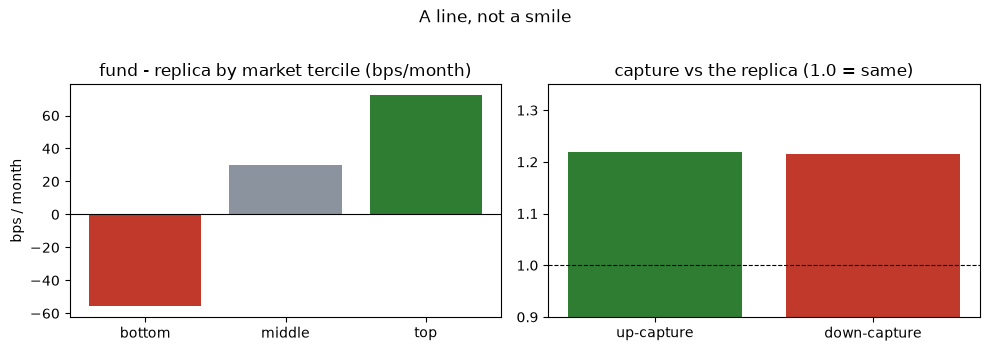

In [5]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
vals = [R['ter_low'], R['ter_mid'], R['ter_high']]
ax[0].bar(['bottom', 'middle', 'top'], vals,
          color=['#c0392b', '#8b949e', '#2e7d32'])
ax[0].axhline(0, color='k', lw=0.8)
ax[0].set_title('fund - replica by market tercile (bps/month)')
ax[0].set_ylabel('bps / month')
ax[1].bar(['up-capture', 'down-capture'], [R['up_cap'], R['dn_cap']],
          color=['#2e7d32', '#c0392b'])
ax[1].axhline(1.0, color='k', lw=0.8, ls='--')
ax[1].set_ylim(0.9, 1.35)
ax[1].set_title('capture vs the replica (1.0 = same)')
fig.suptitle('A line, not a smile', y=1.02)
fig.tight_layout()
plt.show()

## 4. Robustness — era cut, annual refit, and the two judgement calls

Two choices in this design are hindsight-flavoured and must be swept rather than defended. (i) The **QQQ leg**: we know *today* that convertible issuers skew growth, and a richer kit mechanically shrinks the residual we are trying to measure. (ii) The **2017 boundary**. Strip the kit back to what a 2009 observer would have picked, and walk the boundary across seven years.

In [6]:
print(f"2018-2021 (n={R['era_e_n']:,}): alpha {R['era_e_alpha']:+.2f}%/yr  t {R['era_e_t']:+.2f}")
print(f"2022-2026 (n={R['era_l_n']:,}): alpha {R['era_l_alpha']:+.2f}%/yr  t {R['era_l_t']:+.2f}")
print(f"annual refit, always forward (n={R['refit_n']:,}): "
      f"alpha {R['refit_alpha']:+.2f}%/yr  t {R['refit_t']:+.2f}")
print('\nreplication kit sweep (a LEANER kit leaves a BIGGER residual):')
print(f"  SPY only      alpha {R['kit_spy_alpha']:+.2f}%/yr  t {R['kit_spy_t']:+.2f}")
print(f"  SPY+LQD       alpha {R['kit_spylqd_alpha']:+.2f}%/yr  t {R['kit_spylqd_t']:+.2f}")
print(f"  SPY+QQQ       alpha {R['kit_spyqqq_alpha']:+.2f}%/yr  t {R['kit_spyqqq_t']:+.2f}")
print(f"  SPY+QQQ+LQD   alpha {R['alpha_oos']:+.2f}%/yr  t {R['t_oos']:+.2f}   (headline)")
print('\nin-sample boundary sweep, 2014-12-31 ... 2020-12-31:')
print(f"  best  t: alpha {R['split_best_alpha']:+.2f}%/yr  t {R['split_best_t']:+.2f}")
print(f"  worst t: alpha {R['split_worst_alpha']:+.2f}%/yr  t {R['split_worst_t']:+.2f}")
print(f"\n-> across all {R['n_specs']} specifications the largest |t| is "
      f"{R['max_spec_t']:.2f}, and one of them is negative")

2018-2021 (n=1,008): alpha +4.68%/yr  t +0.86
2022-2026 (n=1,126): alpha -0.78%/yr  t -0.23
annual refit, always forward (n=3,141): alpha +1.35%/yr  t +0.61

replication kit sweep (a LEANER kit leaves a BIGGER residual):
  SPY only      alpha +3.01%/yr  t +0.92
  SPY+LQD       alpha +2.99%/yr  t +0.94
  SPY+QQQ       alpha +1.81%/yr  t +0.57
  SPY+QQQ+LQD   alpha +1.80%/yr  t +0.58   (headline)

in-sample boundary sweep, 2014-12-31 ... 2020-12-31:
  best  t: alpha +2.35%/yr  t +0.90
  worst t: alpha -2.72%/yr  t -0.80

-> across all 11 specifications the largest |t| is 0.94, and one of them is negative


> 💡 **In plain words** — what little residual exists is a 2018-2021 artefact, the SPAC-and-growth-issuance boom when convertible issuers were exactly the names that ran. Refitting the recipe every year and always applying it forward gives the same *t* of 0.61. And the QQQ leg is not what buried the fund: **take it away and the residual gets larger** (+3.01%/yr) while the *t* stays under 1. The blank belongs to the fund, not to the specification.

## 5. Cost / fee sweep and the ICVT cross-check

Turnover is trivial, so friction cannot decide this — and charging the replica's *own* fee honestly makes the residual **larger**, not smaller.

In [7]:
print(f"0 bps cost, 0 bps/yr replica fee : alpha {R['cost0_alpha']:+.2f}%/yr (t {R['cost0_t']:+.2f})")
print(f"10 bps cost, 20 bps/yr replica fee: alpha {R['cost10_alpha']:+.2f}%/yr (t {R['cost10_t']:+.2f})")
print(f"-> the whole 4x3 grid moves alpha by 22 bps/yr and t by 0.08")
print(f"\nICVT (n={R['icvt_n']:,}): alpha {R['icvt_alpha']:+.2f}%/yr (t {R['icvt_t']:+.2f})")
print(f"  up-capture {R['icvt_up']:.3f} < down-capture {R['icvt_dn']:.3f}  "
      f"-> mildly CONCAVE, the opposite of the pitch")
print(f"\nMarch 2020: fund {R['mar20_fund']:+.2f}% vs replica {R['mar20_repl']:+.2f}% "
      f"(shortfall {R['mar20_gap']:+.2f}% in one month)")

0 bps cost, 0 bps/yr replica fee : alpha +1.69%/yr (t +0.54)
10 bps cost, 20 bps/yr replica fee: alpha +1.91%/yr (t +0.62)
-> the whole 4x3 grid moves alpha by 22 bps/yr and t by 0.08

ICVT (n=1,378): alpha -2.16%/yr (t -0.56)
  up-capture 0.802 < down-capture 0.871  -> mildly CONCAVE, the opposite of the pitch

March 2020: fund -13.28% vs replica -6.49% (shortfall -6.79% in one month)


## 6. Live synthetic control — the machinery is unbiased

Planted world: a fund that is a static mix **plus** a 2%/yr alpha **plus** a delta ratchet (equity exposure rising after rallies, falling after selloffs — exactly what a real convertible does). Null world: both switched off. The harness must recover the first and report nothing on the second. Machinery proof only — never market evidence.

In [8]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath(os.path.join('..','..','..')))
import numpy as np
from convert_repl import data, strategy as st
pl = st.synthetic_detect(data.synthetic_panel(signal_strength=1.0, seed=953)[0])
print('planted: weights recovered', {k: round(v, 3) for k, v in pl['weights'].items()},
      '(true 0.30 / 0.20 / 0.35)')
print('planted: OOS alpha %+.2f%%/yr (t %+.2f), TM gamma %+.2f (t %+.2f), smile %+.1f bps'
      % (pl['alpha_oos_ann']*100, pl['t_oos'], pl['tm_gamma'], pl['t_tm_gamma'], pl['smile_bps']))
nl = np.array([[d['t_oos'], d['t_tm_gamma']] for d in
               (st.synthetic_detect(data.synthetic_panel(signal_strength=0.0, seed=953+s)[0])
                for s in range(8))])
print('null x8: alpha t mean %+.2f (sd %.2f), |t|>=2 in %d/8; gamma t mean %+.2f, |t|>=2 in %d/8'
      % (nl[:,0].mean(), nl[:,0].std(ddof=1), (abs(nl[:,0])>=2).sum(),
         nl[:,1].mean(), (abs(nl[:,1])>=2).sum()))

planted: weights recovered {'eq': 0.308, 'growth': 0.202, 'credit': 0.334} (true 0.30 / 0.20 / 0.35)
planted: OOS alpha +5.02%/yr (t +3.97), TM gamma +0.73 (t +3.45), smile +26.7 bps


null x8: alpha t mean +0.03 (sd 0.87), |t|>=2 in 0/8; gamma t mean +0.01, |t|>=2 in 0/8


## Verdict

- **Signal — None.** The out-of-sample residual over a frozen, long-only, three-ETF-plus-cash replication is **+1.80%/yr, HAC *t* = +0.58**, bootstrap CI **[-4.47%, +7.55%]** — the desk's bar is |*t*| ≥ 2, and this is a quarter of it. It is not era-robust (+4.68%/yr then -0.78%/yr), survives no better under an annual refit (*t* = +0.61), never clears |*t*| = 0.94 across 11 kit-and-boundary specifications, and flips sign on ICVT (-2.16%/yr, *t* = -0.56). The convexity claim fails independently and more decisively: up-capture 1.219 ≈ down-capture 1.215 (asymmetry +0.004), tail smile -21.6 bps/month (*t* = -0.50), Treynor-Mazuy γ = +0.192 (*t* = +0.25). **Survivorship** is named on this axis: CWB and ICVT are two *surviving* listed funds, so the sample is if anything tilted in the wrapper's favour.
- **Tradability — Mirage.** Nothing banks. The long side pays a certain 0.40%/yr for a coin-flip residual; the short-the-wrapper side needs to run a 7.8%/yr monthly tracking error to harvest a 2%/yr expectation whose realised path includes a -6.8% month. The result is a *classification*, not a trade: a convertible ETF is a 57/6/37 equity/credit/cash sleeve, and the fee is the only part of it you can forecast.